In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fusionGeneAnalysis
import dansy
from chimerdb_cleanup_utilities import *
import liftover
from collections import Counter
import seaborn as sns
import itertools
import fusionClasses as fc
import scipy.stats as stats

In [2]:
# Creating some default parameters for future plots.
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 300
plt.rcParams['legend.edgecolor'] = 'k'
plt.rcParams['legend.fancybox'] = False

Creating a few useful functions for this notebook

In [3]:
# Creating a quick Frame fixing function
def fix_frame_str(x:str):
    new_x = x.replace("'",'').lower()
    return new_x

def check_tcga_id(x):

    if len(x) > 12 and 'TCGA' in x:
        y = x[0:12]
    else:
        y=x
    return y

### Importing necessary databases and useful files

In [4]:
gene_ID_conv_clean = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
full_exon_information = pd.read_csv('Gene_exon_information.csv')
converter = liftover.get_lifter('hg19', 'hg38', one_based=True)

In [5]:
# To start I am just going to work with the GBM dataset
chimerdb = pd.read_excel('ChimerSeq4.xlsx')
chimerdb['H_gene'] = chimerdb.apply(fix_datetime_names,args = ['Fusion_pair','H_gene',0],axis=1)
chimerdb['T_gene'] = chimerdb.apply(fix_datetime_names,args = ['Fusion_pair','T_gene',1],axis=1)

In [6]:
cancersOI = ['GBM','LAML','PAAD','LUAD','PRAD','OV','THCA','LGG','LUSC','BRCA','UCS','UCEC','KICH','KIRC','KIRP','LIHC','COAD','CHOL','CESC','PCPG','TGCT','SKCM','ESCA','HNSC','BLCA','STAD','SARC','ACC','DLBC','MESO','READ','THYM','UVM']
fusion_info = fusionGeneAnalysis.retrieve_cancer_fusion_data(chimerdb, cancersOI)
print(len(cancersOI))

33


In [7]:
# Now let's limit it to a set version of the frames
#acceptable_frames = ['5utr-cds', '5utr-5utr','cds-5utr','3utr-5utr', 'cds-3utr','3utr-cds', '3utr-3utr', 'in-frame']
acceptable_frames = ['5utr-cds', '5utr-5utr','cds-5utr','cds-3utr','in-frame']
fusion_info.dropna(subset = 'Frame',inplace=True)
fusion_info['Frame'] = fusion_info.Frame.apply(fix_frame_str)
fusion_info = fusion_info[fusion_info.Frame.isin(acceptable_frames)]

Now to getting the baseline DANSy network for establishing the natural proteome results.

In [8]:
# Importing the full proteome n-gram analysis
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='2026_0715.csv')
proteome_net = dansy.dansy(ref=ref_df, n=15)

# Getting the full set of naturally occuring n-grams to pass on to the fusion gene analysis
nat_ngrams_ids = set(proteome_net.ngrams).union(proteome_net.collapsed_ngrams)
interpro_dict = proteome_net.interpro_conversion

Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


# ChimerDB Dataset Cleanup

A major strength of ChimerDB is that it contains breakpoints detected by multiple tools for several samples with each as their own entry. However, as multiple entries can represent the same breakpoint this creates several instances of the same potential fusion protein. We have to now filter out the redundant information to ensure we only keep unique breakpoints for the same patient. As a secondary issue that occurs as well is unique to the TCGA cohort. For some programs that ChimerDB aggregated data from the Sample ID is the base patient TCGA ID, while others are the specific sample/aliquot ID. We have to collapse this information together as well.

A closer inspection of the breakpoint data also highlights another small issue that complicates the analysis. The Tophat-Fusion analysis has a "different" breakpoint. The breakpoint is a single base pair different than the rest. And this is a recurring thing I have noticed throughout suggesting that the Tophat-Fusion program runs with 0-indexing, while the rest run with 1-indexing.

So, below I am aggregating data to remove duplicated/unnecessary information. The cleaner functions are found in [chimerdb_cleanup_utilities](chimerdb_cleanup_utilities.py) which include the following functions:
- check_for_tophat
- check_tophat_pos
- compare_hg19_hg38
- inner_hg_build_comp
- check_for_collapsing*
- fix_datetime_names

The functions with * are used in this script the rest are internal functions

In [9]:
# First let's tackle the Tophat-Fusion issue. I will check that for every common fusion with a Tophat-fusion source and a secondary one is actually off by one

# Limiting the analysis to everything that is not an out-of-frame fusion
chimer_filt = fusionGeneAnalysis.retrieve_cancer_fusion_data(chimerdb, cancersOI)
chimer_filt.dropna(subset = 'Frame',inplace=True)
chimer_filt['Frame'] = chimer_filt.Frame.apply(fix_frame_str)
chimer_filt = chimer_filt[chimer_filt.Frame.isin(acceptable_frames)]

# Now grouping based on the fusion pair and the Barcode ID to find the unique potential ones
grouped_db = chimer_filt.groupby(['BarcodeID', 'Fusion_pair'])

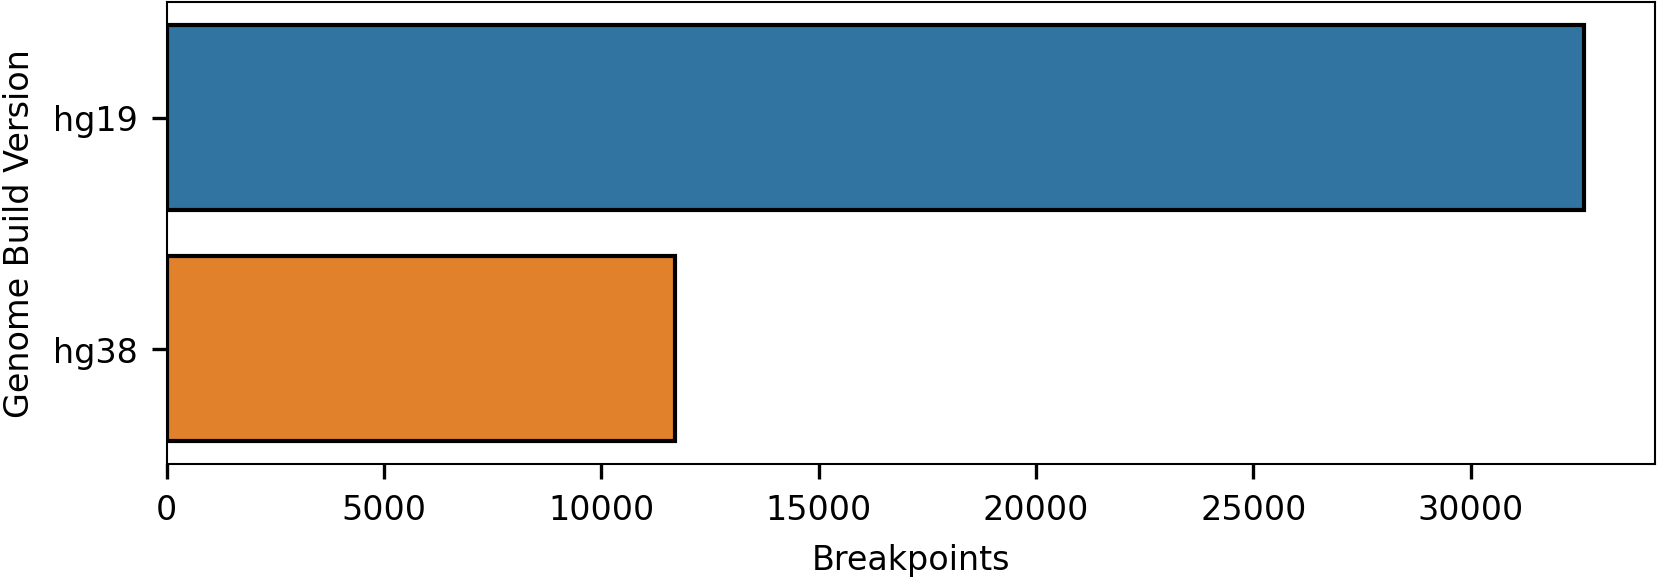

In [10]:
sns.countplot(chimer_filt, y = 'Genome_Build_Version', hue = 'Genome_Build_Version',edgecolor = 'k', linewidth=1)
plt.ylabel('Genome Build Version', size = 8)
plt.xlabel('Breakpoints', size = 8)
plt.gcf().set_figheight(2)
plt.show()

In [11]:
# Now that I have done some checking of everything it seems like it all is working correctly. The last thing that I need to do is check if the same fusions are coming from the same samples but because of how the barcodes are being provided are showing up as separately. For this I will be looking for barcodes which have the same first 3 components (i.e. TCGA-XX-NNNN without the additional -01A or variant of that) and fusion pair. If they have the same one I will then check the coordinates of what was kept and then collapse as necessary.

overlap_cands = []
for outer_group in grouped_db.groups.keys():
    for inner_group in grouped_db.groups.keys():
        if outer_group != inner_group:
            overlap_id = inner_group[0] in outer_group[0]
            same_fusion = inner_group[1] == outer_group[1]
            if overlap_id and same_fusion:
                overlap_cands.append([outer_group, inner_group])

In [12]:
chimer_filt_alt = chimer_filt.copy()
chimer_filt_alt['BarcodeID'] = chimer_filt_alt['BarcodeID'].apply(check_tcga_id)

In [13]:

grouped_alt = chimer_filt_alt.groupby(['BarcodeID', 'Fusion_pair'])
idxkeepers = []
codes = []
closerlook = []
for group in grouped_alt.groups.keys():
    x,status = check_for_collapsing(grouped_alt.get_group(group), converter)
    idxkeepers.append(x)
    codes.append(status)
code_mapper = {6:'Single', 1:'Tophat Collapse', 2: 'hg38 Overlap kept', 8:'Multiple hg38 breakpoints',7:'Multiple hg19 breakpoints tophat collapse', 3:'hg38 kept over tophat',4:'hg38 kept no tophat', 5:'Collapsed no tophat', 0:'No collapse'}      
{code_mapper[k]:v for k,v in Counter(codes).items()}

{'Single': 4257,
 'Collapsed no tophat': 2266,
 'No collapse': 1553,
 'hg38 kept no tophat': 9498,
 'Multiple hg38 breakpoints': 199,
 'hg38 Overlap kept': 156,
 'Tophat Collapse': 54,
 'hg38 kept over tophat': 8,
 'Multiple hg19 breakpoints tophat collapse': 3}

In [14]:
collapsed_chimer = chimerdb.filter(sorted(itertools.chain.from_iterable(idxkeepers)), axis = 0)
print(f'There are {len(collapsed_chimer)} unique fusion breakpoints')

There are 25361 unique fusion breakpoints


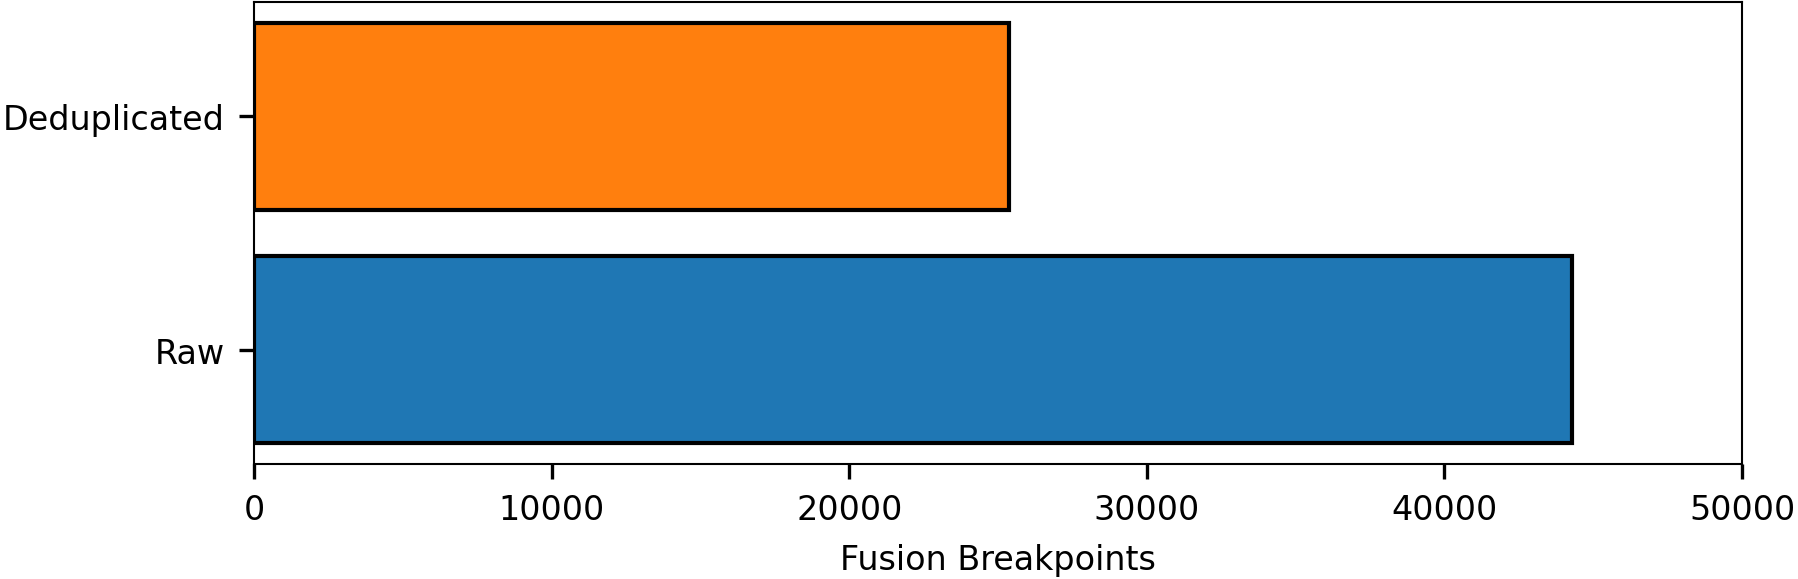

In [15]:
plt.barh(['Raw', 'Deduplicated'],[len(chimer_filt), len(collapsed_chimer)], color = ['tab:blue','tab:orange'], edgecolor = 'k', linewidth = 1)
plt.gcf().set_figheight(2)
plt.xlabel('Fusion Breakpoints', size = 8)
plt.xticks(np.arange(0,60000,10000))
plt.show()

Now, we need to do a little bit more cleanup to conduct the analysis. We first need to map the gene names to an ENSEMBL ID to make converting to a UniProt ID (when available) consistent. This includes ensuring the gene names did not get converted to dates when applicable and other small formatting issues.

In [16]:
# Get the initial conversion information for the genes that are present
quick_ensembl = fusionGeneAnalysis.extract_fusion_ensembl(collapsed_chimer, gene_ID_conv_clean)
collapsed_chimer['H_ENSEMBL'] = collapsed_chimer['H_gene'].map(quick_ensembl)
collapsed_chimer['T_ENSEMBL'] = collapsed_chimer['T_gene'].map(quick_ensembl)

# Getting some information on which gene names needed to be verified for accuracy (this includes chromosome location and gene name formatting)
change_map = {}
upper_count = 0
for idx, row in collapsed_chimer.iterrows():
    changer = {}
    ou = []
    for prefix in ['H_', 'T_']:
        chrom = row[prefix+'chr']
        pos = row[prefix+'position']

        # Convert breakpoint positions to the current genome build when necessary by lifting over (lo)
        lo = True
        if row['Genome_Build_Version'] == 'hg19':
            chrom2, pos = converter.query(chrom, pos)[0][0:2]
            lo = chrom2 == chrom

        # Make sure the chromosome and gene is correct    
        chrom = chrom[3:]
        gene_stuff = {'Gene':row[prefix+'gene'],
                      'Chromosome':chrom,
                      'Position':pos}
        v,u, new_ensembl = fusionGeneAnalysis.verify_fusion_gene(gene_stuff, quick_ensembl, gene_ID_conv_clean)
        if v and lo:
            if new_ensembl != row[prefix+'ENSEMBL']:
                changer[prefix] = new_ensembl
        else:
            changer[prefix] = None
        ou.append(u)
    
    if any(ou):
        upper_count += 1
    if changer:
        change_map[idx] = changer

print(f'There were {upper_count} fusion(s) requiring upppercase.')
new_collapsed_chimer = collapsed_chimer.copy()
for idx, dets in change_map.items():
    for prefix, new_val in dets.items():
        new_collapsed_chimer.loc[idx,prefix+'ENSEMBL'] = new_val

comp_collapse_chimer = new_collapsed_chimer.dropna(subset=['H_ENSEMBL', 'T_ENSEMBL']).copy()
dropped_num = len(new_collapsed_chimer) - len(comp_collapse_chimer)
print(f'There were {dropped_num} that were dropped due to missing gene information')

mapper = {'h_gene':'H_ENSEMBL','t_gene':'T_ENSEMBL', 'h_chr':'H_chr','t_chr':'T_chr','h_pos':'H_position','t_pos':'T_position', 'h_strand':'H_strand','t_strand':'T_strand', 'genome_build':'Genome_Build_Version','name':'Fusion_pair'}

There were 521 fusion(s) requiring upppercase.
There were 751 that were dropped due to missing gene information


In [17]:
# Some additional information that can be useful for downstream analysis to include/summarize in the output
comp_collapse_chimer['Kinase_involved'] = (~comp_collapse_chimer['H_kinase'].isna()) | (~comp_collapse_chimer['T_kinase'].isna())
comp_collapse_chimer['TF_involved'] = (~comp_collapse_chimer['H_transcription_factor'].isna()) | (~comp_collapse_chimer['T_transcription_factor'].isna())
comp_collapse_chimer['TS_involved'] = (~comp_collapse_chimer['H_tumor_suppressor'].isna()) | (~comp_collapse_chimer['T_tumor_suppressor'].isna())
comp_collapse_chimer['Oncogene_involved'] = (~comp_collapse_chimer['H_oncogene'].isna()) | (~comp_collapse_chimer['T_oncogene'].isna())

In [18]:
# Now as a final statement before going into the actual fusion analysis:
i = len(comp_collapse_chimer['Fusion_pair'].unique())
print(f'There are {i} unique fusion protein pairs')

There are 14323 unique fusion protein pairs


# Now getting the fusion gene results.

In [19]:
tcga_chimer_res = fc.fusionCollection(comp_collapse_chimer, mapper,add_cols=['BarcodeID','Cancertype','Frame','Kinase_involved','TF_involved','TS_involved','Oncogene_involved'],)

100%|██████████| 24610/24610 [01:39<00:00, 246.28it/s]


In [20]:
tcga_chimer_res.perform_dansy_analysis(proteome_net)
tcga_sum = tcga_chimer_res.summarize_dansy_results().dropna()

100%|██████████| 5684/5684 [00:10<00:00, 524.20it/s]


There were 2258 fusion domain architectures previously found in the proteome.


In [ ]:
fusion_dansy_summary = tcga_sum.copy()
fusion_dansy_summary['PatientID'] = fusion_dansy_summary['BarcodeID'].apply(check_tcga_id)
fusion_dansy_summary.to_csv('260324_Individual_Fusion_Summary_info.csv')

In [22]:
broad_summary = tcga_sum.value_counts(subset=['Cancertype', 'dansy_impact']).reset_index().pivot(columns='dansy_impact', index = 'Cancertype', values='count').fillna(0)
row_order = broad_summary.sum(axis = 1).sort_values(ascending=False).index

# Normalizing really quick
norm_summary = broad_summary.copy()
norm_summary = norm_summary.div(norm_summary.sum(axis=1),axis=0)

# Reordering the columns to put them in an order I prefer for visualization
norm_summary = norm_summary[['Novel','Pre-existing','No Annotation']]
norm_summary = norm_summary.reindex(row_order)
fusion_counts = broad_summary.sum(axis=1).sort_values(ascending=False).astype(int)

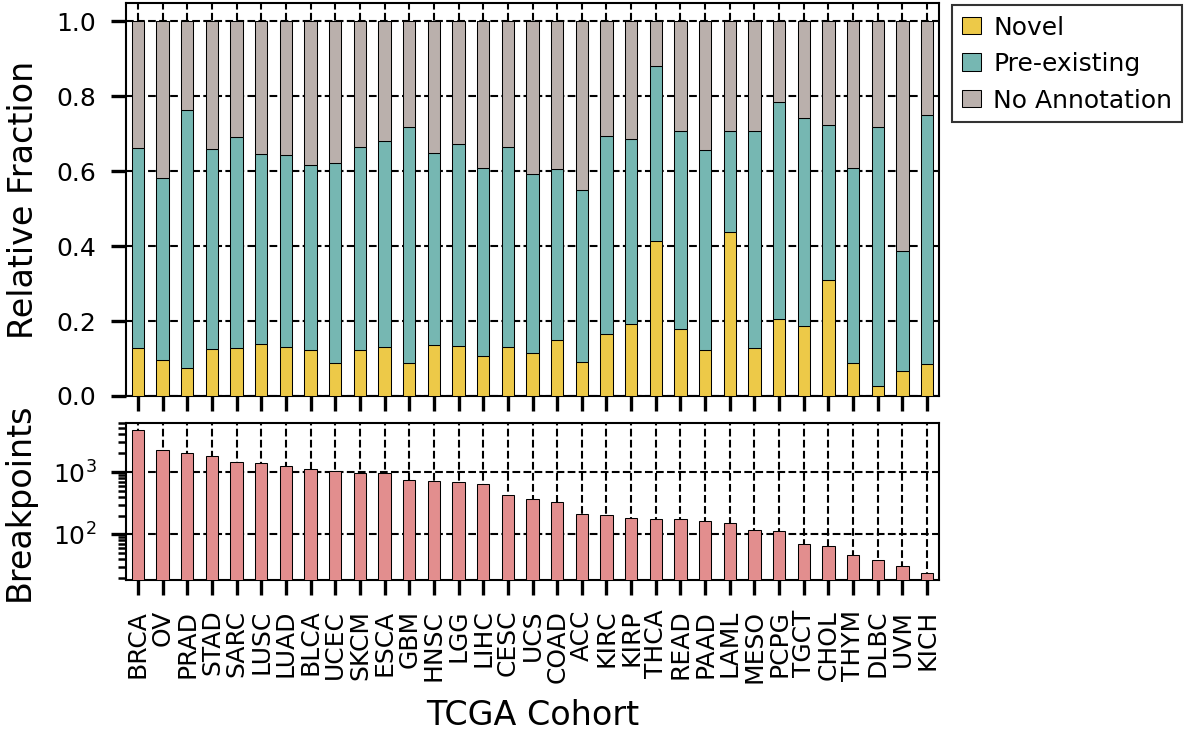

In [23]:
f, axs = plt.subplots(nrows=2, sharex=True, height_ratios=[2.5,1],gridspec_kw={'hspace':0.1})

# Creating the relative fraction plot of each DANSy fusion category
norm_summary.plot(kind='bar', stacked=True, ax = axs[0],width = 0.5,edgecolor='k', linewidth = 0.25, color = ['#EDC948','#76B7B2','#bab0ac'], zorder =10)
axs[0].legend(bbox_to_anchor = (1,1.025), handlelength = 0.75, handletextpad = 0.5, fontsize = 6).get_frame().set_linewidth(0.5)
axs[0].set_ylabel('Relative Fraction', size = 8)
axs[0].tick_params(labelsize = 6)
axs[0].grid(zorder = 0, ls='--', color = 'k', axis = 'both', lw = 0.5)

# Creating the breakpoints count plot
fcounts = pd.DataFrame(fusion_counts)
fcounts['Cancer'] = fcounts.index
fcounts.rename(columns={0:'Fusions'},inplace=True)
sns.barplot(fcounts, y = 'Fusions', x = 'Cancer', edgecolor = 'k', linewidth = 0.25, ax = axs[1], legend=None,width=0.5,
            color = 'lightcoral', zorder = 10)
axs[1].set_ylabel('Breakpoints', size = 8)
axs[1].set_xlabel('TCGA Cohort', size = 8)
axs[1].set_yscale('log')
axs[1].tick_params(labelsize = 6)
axs[1].grid(zorder = 0, ls='--', color = 'k', axis = 'both', lw = 0.5)
plt.xticks(rotation = 90)
plt.gcf().set_figwidth(3.5)
plt.gcf().set_figheight(2.5)
plt.savefig('Figures/Manuscript/Figure_3/3B_TCGA_Fusion_DANSY_Categories.svg')

As a supplementary figure, we are showing just the fraction of novel domain architectures that can undergo the two different methods.

In [24]:
tcga_chimer_detailed = fc.fusionCollection(comp_collapse_chimer, mapper,add_cols=['BarcodeID','Cancertype','Frame','Kinase_involved','TF_involved','TS_involved','Oncogene_involved'], detailed_novel=True)
tcga_chimer_detailed.perform_dansy_analysis(proteome_net)
tcga_detailed = tcga_chimer_detailed.summarize_dansy_results().dropna()

100%|██████████| 5790/5790 [00:16<00:00, 359.23it/s]


There were 2302 fusion domain architectures previously found in the proteome.


In [25]:
broad_summary_det = tcga_detailed.value_counts(subset=['Cancertype', 'dansy_impact']).reset_index().pivot(columns='dansy_impact', index = 'Cancertype', values='count').fillna(0)
row_order = broad_summary_det.sum(axis = 1).sort_values(ascending=False).index
norm_summary_det = broad_summary_det.copy()
norm_summary_det.drop(['No Annotation','Pre-existing'], axis = 1, inplace=True)
norm_summary_det = norm_summary_det.div(norm_summary_det.sum(axis=1),axis=0)
norm_summary_det = norm_summary_det.reindex(row_order)

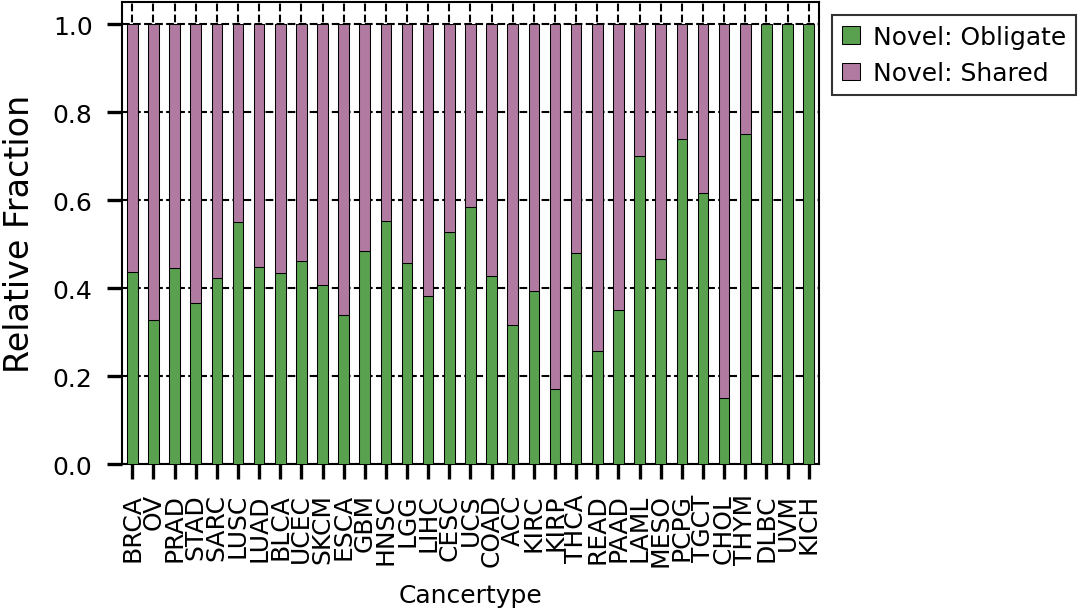

In [26]:
norm_summary_det.plot(kind='bar', stacked=True,width = 0.5,edgecolor='k', linewidth = 0.25, color = ['#59a14f','#b07aa1'], zorder = 10)
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(3,2)
plt.legend(bbox_to_anchor = (1,1), handlelength = 0.75, handletextpad = 0.5, fontsize = 6).get_frame().set_linewidth(0.5)
plt.ylabel('Relative Fraction', size = 8)
plt.tick_params(labelsize = 6)
plt.grid(zorder = -1, ls='--', color = 'k', axis = 'both', lw = 0.5)
plt.savefig('Figures/Manuscript/Supplemental_Figure_11/Novel_Domain_Subcategory_Breakdown.svg')

Now as a quick analysis let me check the number of unique architectures relative to the number of unique fusion pairs

In [27]:
tcga_sum_group = tcga_sum.groupby('Cancertype')
temp_innter = []
for can in cancersOI:
    x1 = tcga_sum_group.get_group(can)
    x2 = x1.groupby('dansy_impact')
    for group in x2.groups:
        num_archs = len(x2.get_group(group).domain_architecture.unique())
        num_uni_fusions = len(x2.get_group(group).name.unique())
        num_breakpoints = len(x2.get_group(group))
        temp_innter.append([can, group, num_archs, num_uni_fusions, num_breakpoints])
        # if "Novel" in group:
        #     if num_uni_fusions != num_archs:
        #         x3 = x2.get_group(group).filter(['name','domain_architecture']).drop_duplicates()
        #         prots = x3[x3['name'].duplicated()]['name'].unique()

In [28]:
num_summary = pd.DataFrame.from_records(temp_innter, columns=['Cancer','Category','Architectures','Fusions','Total'])

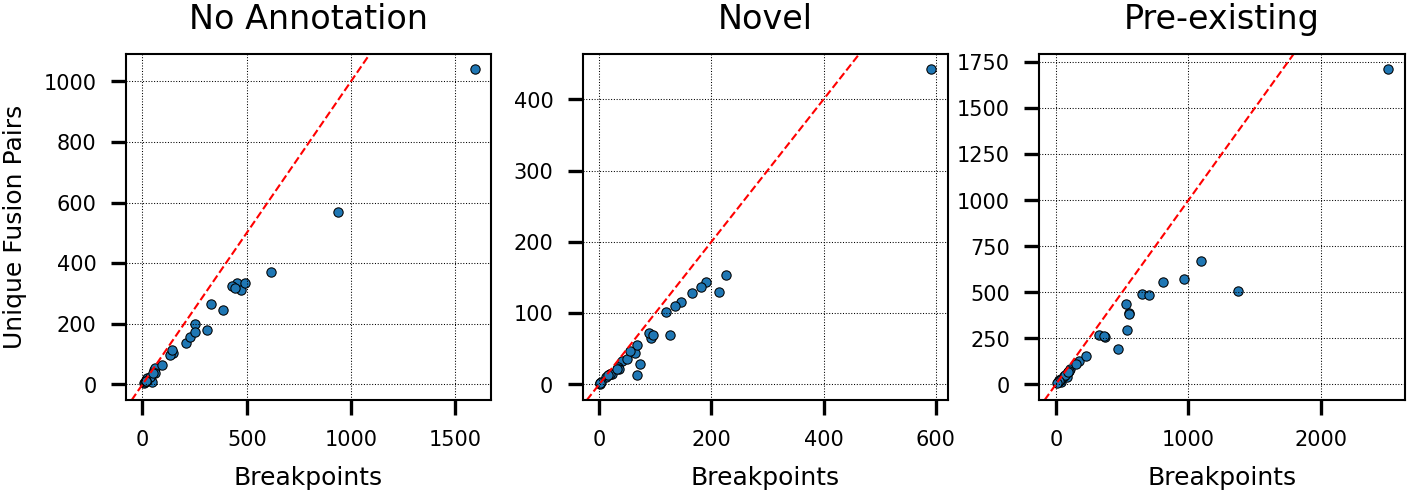

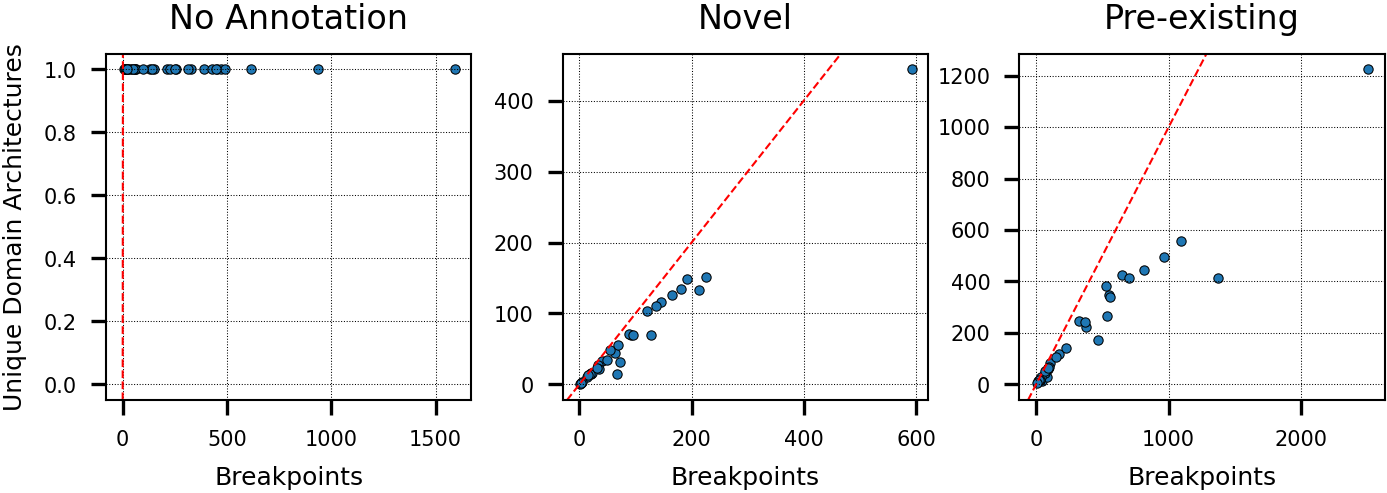

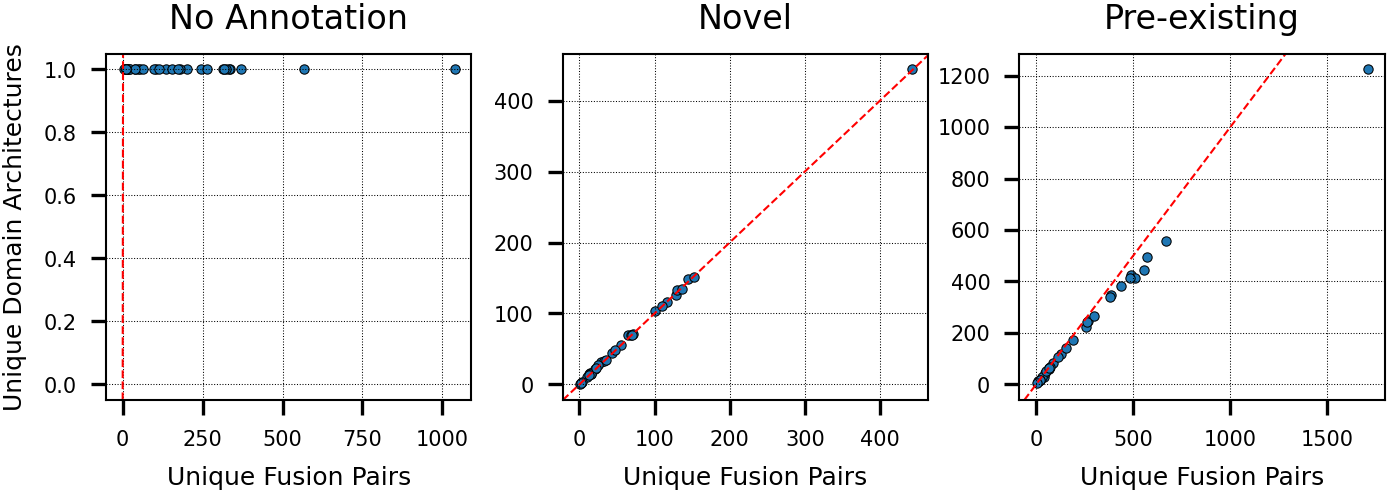

In [29]:
# Now plotting as a potential supplementary figure
f, axs = plt.subplots(1,3, figsize=(5.5,1.5),gridspec_kw={'wspace':0.25} )
for i,cat in enumerate(num_summary.Category.unique()):
    temp = num_summary[num_summary.Category == cat]
    axs[i].scatter(y = temp.Fusions, x = temp.Total, s = 5, linewidth = 0.25, edgecolor = 'k')
    axs[i].axline((0,0),slope=1, ls = '--', color = 'r', linewidth = 0.5)
    
    axs[i].set_title(cat, size = 8)
    axs[i].set_xlabel('Breakpoints', size = 6)
    if i == 0:
        axs[i].set_ylabel('Unique Fusion Pairs', size = 6)
    axs[i].tick_params(labelsize = 5)
    axs[i].grid(zorder = 0, ls=':', color = 'k', axis = 'both', lw = 0.25)
plt.savefig('Figures/Manuscript/Supplemental_Figure_11/11A_Breakpoint_Unique_Fusions.svg')

# Now plotting as a potential supplementary figure
f, axs = plt.subplots(1,3, figsize=(5.5,1.5),gridspec_kw={'wspace':0.25} )
for i,cat in enumerate(num_summary.Category.unique()):
    temp = num_summary[num_summary.Category == cat]
    axs[i].scatter(y = temp.Architectures, x = temp.Total, s = 5, linewidth = 0.25, edgecolor = 'k')
    axs[i].axline((0,0),slope=1, ls = '--', color = 'r', linewidth = 0.5)
    axs[i].set_title(cat, size = 8)
    axs[i].set_xlabel('Breakpoints', size = 6)
    if i == 0:
        axs[i].set_ylabel('Unique Domain Architectures', size = 6)
    axs[i].tick_params(labelsize = 5)
    axs[i].grid(zorder = 0, ls=':', color = 'k', axis = 'both', lw = 0.25)
plt.savefig('Figures/Manuscript/Supplemental_Figure_11/11B_Breakpoint_Unique_Archs.svg')

# Now plotting as a potential supplementary figure
f, axs = plt.subplots(1,3, figsize=(5.5,1.5),gridspec_kw={'wspace':0.25} )
for i,cat in enumerate(num_summary.Category.unique()):
    temp = num_summary[num_summary.Category == cat]
    axs[i].scatter(y = temp.Architectures, x = temp.Fusions, s = 5, linewidth = 0.25, edgecolor = 'k')
    axs[i].axline((0,0),slope=1, ls = '--', color = 'r', linewidth = 0.5)
    axs[i].set_title(cat, size = 8)
    axs[i].set_xlabel('Unique Fusion Pairs', size = 6)
    if i == 0:
        axs[i].set_ylabel('Unique Domain Architectures', size = 6)
    axs[i].tick_params(labelsize = 5)
    axs[i].grid(zorder = 0, ls=':', color = 'k', axis = 'both', lw = 0.25)
plt.savefig('Figures/Manuscript/Supplemental_Figure_11/11C_Archs_Unique_Fusions.svg')

Also as part of this checking how many patients had multiple breakpoints for the same fusion pair

In [30]:
patient_res = tcga_sum.copy()
patient_res['PatientID'] = patient_res['BarcodeID'].apply(check_tcga_id)
patient_res = patient_res.groupby('PatientID')
pt_bp_dist = pd.Series(index=['Single BP', 'Multiple Fusions Single BP','Single Fusion Multiple BP','Multiple Fusions Multiple BP'], dtype=int).fillna(0)
pt_dansy_dist = pd.Series(index=['Multiple Fusions Multiple Impacts','Single Fusion Multiple Impacts','Single Fusion Single Impact'], dtype=int).fillna(0)
pt_arch_dist = pd.Series(index=['Multiple Fusion Multiple Architectures','Single Fusion Multiple Architectures','Single Fusion Single Architecture'], dtype=int).fillna(0)
pt_uni_prots = pd.Series(index = ['Single', 'Multiple'], dtype = int).fillna(0)
idxOI = []
for patient in patient_res.groups:
    
    x = patient_res.get_group(patient)

    # Check the number of breakpoints and fusion proteins
    check_arch = False
    if len(x) == 1:
        pt_bp_dist['Single BP'] += 1
    elif len(x) == len(x['name'].unique()):
        pt_bp_dist['Multiple Fusions Single BP'] += 1
    elif len(x['name'].unique()) == 1:
        pt_bp_dist['Single Fusion Multiple BP'] += 1
        check_arch = True
    else:
        pt_bp_dist['Multiple Fusions Multiple BP'] += 1
        check_arch = True

    # Check the number of fusion genes
    if len(x['name'].unique()) == 1:
        pt_uni_prots.Single +=1
    else:
        pt_uni_prots.Multiple += 1

    # Domain architectures, which should be the same as above
    # Check the dansy impacts
    temp = x.filter(['name', 'domain_architecture']).drop_duplicates()
    multi_arch = False
    if check_arch:
        if len(x) == 1:
            pass
        elif len(x['name'].unique()) == 1 and len(x['domain_architecture'].unique()) > 1:
            pt_arch_dist['Single Fusion Multiple Architectures'] += 1
            multi_arch = True
        elif len(x['name'].unique()) == 1 and len(x['domain_architecture'].unique()) == 1:
            pt_arch_dist['Single Fusion Single Architecture'] += 1
        elif len(x) == len(temp) or len(temp.name.unique()) == len(temp):
            pt_arch_dist['Single Fusion Single Architecture'] += 1 
        else:
            pt_arch_dist['Multiple Fusion Multiple Architectures'] += 1
            multi_arch = True

    # Check the dansy impacts of those with multiple architectures or breakpoints
    if multi_arch:
        get_index = False
        temp = x.filter(['name', 'dansy_impact']).drop_duplicates()
        if len(x['name'].unique()) == 1 and len(x['dansy_impact'].unique()) > 1:
            pt_dansy_dist['Single Fusion Multiple Impacts'] += 1
            get_index = True
        elif len(x['name'].unique()) == 1 and len(x['dansy_impact'].unique()) == 1:
            pt_dansy_dist['Single Fusion Single Impact'] += 1
        elif len(x) == len(temp) or len(temp.name.unique()) == len(temp):
            pass #pt_dansy_dist.Multi_Prots_Unique_Impact += 1 
        else:
            pt_dansy_dist['Multiple Fusions Multiple Impacts'] += 1
            get_index = True

        if get_index:
            idxOI.append(temp[temp['name'].duplicated(keep=False)].index)

idxOI = list(itertools.chain.from_iterable(idxOI))

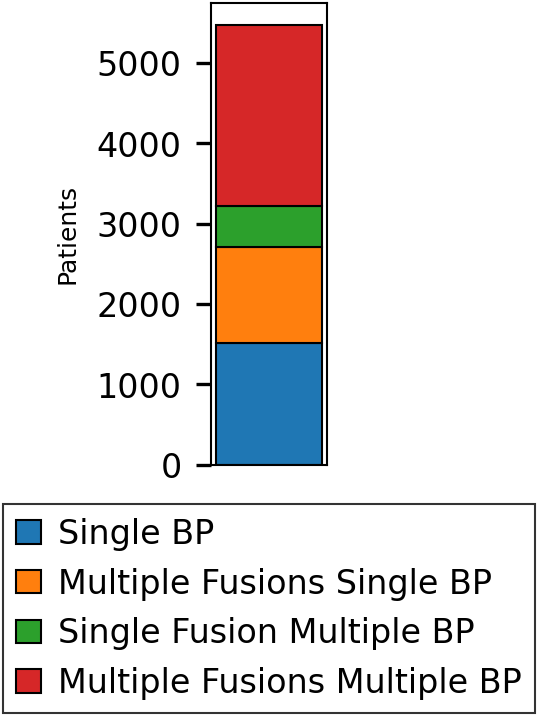

In [31]:
f, ax = plt.subplots(figsize = (0.5,2))
bottom = 0
for lab,i in pt_bp_dist.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom, edgecolor='k', linewidth = 0.5)
    bottom += i
ax.legend(loc = 'upper center', bbox_to_anchor = [0.5,-0.05], handlelength = 0.75, handletextpad = 0.5).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False)
plt.ylabel('Patients')
plt.savefig('Figures/Manuscript/Supplemental_Figure_12/12A_Breakpoint_Protein_breakdown.svg')

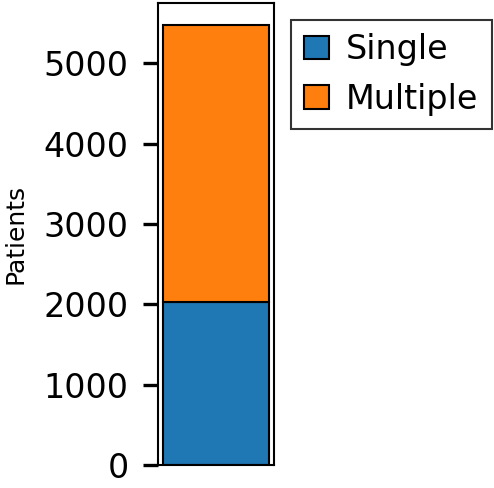

In [32]:

f, ax = plt.subplots(figsize = (0.5,2))
bottom = 0
for lab,i in pt_uni_prots.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom, edgecolor = 'k', linewidth = 0.5)
    bottom += i
ax.legend(bbox_to_anchor = [1,1],handlelength = 0.75, handletextpad = 0.5).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False)
plt.ylabel('Patients')
plt.savefig('Figures/Manuscript/Supplemental_Figure_12/12A_Patient_Fusions_breakdown.svg')

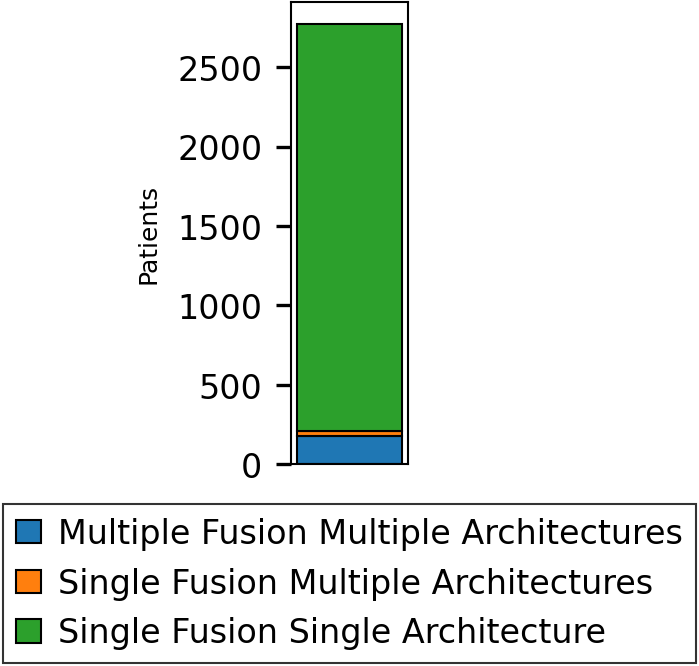

In [33]:

f, ax = plt.subplots(figsize = (0.5,2))
bottom = 0
for lab,i in pt_arch_dist.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom, edgecolor = 'k', linewidth = 0.5)
    bottom += i
ax.legend(loc = 'upper center', bbox_to_anchor = [0.5,-.05], handlelength = 0.75, handletextpad = 0.5).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False)
plt.ylabel('Patients')
plt.savefig('Figures/Manuscript/Supplemental_Figure_12/12C_Multibreakpoint_Arch_breakdown.svg')

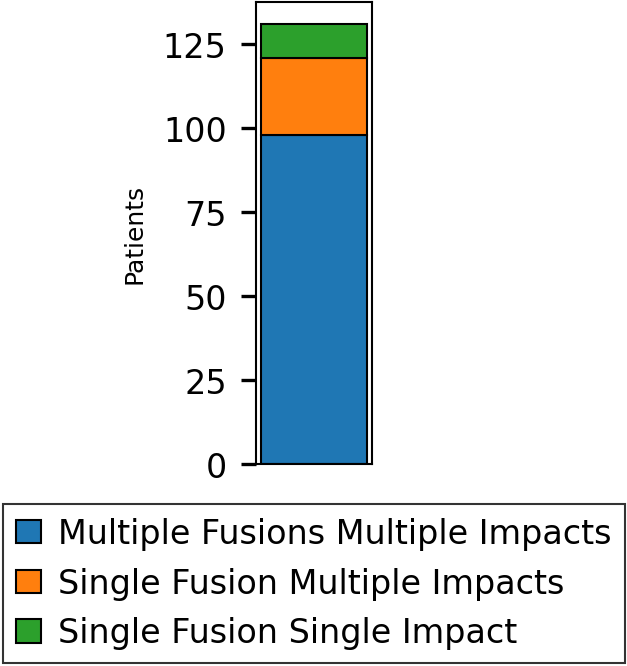

In [34]:

f, ax = plt.subplots(figsize = (0.5,2))
bottom = 0
for lab,i in pt_dansy_dist.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom, edgecolor = 'k', linewidth = 0.5)
    bottom += i
ax.legend(loc = 'upper center', bbox_to_anchor = [0.5,-0.05], handlelength = 0.75, handletextpad = 0.5).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False)
plt.ylabel('Patients')
plt.savefig('Figures/Manuscript/Supplemental_Figure_12/12D_Breakpoint_DANSY_breakdown.svg')

# Looking at recurrent fusions and their general categories

In [49]:
# Getting the recurrent fusions
recurrent_info = fusion_dansy_summary.copy().filter(['PatientID','name','Cancertype','dansy_impact', 'domain_architecture'], axis = 1).drop_duplicates()
nonrecurrent = recurrent_info.copy()
recurrent_genes = recurrent_info[recurrent_info.filter(['PatientID','name']).duplicated(subset= 'name', keep=False)].name.unique()
recurrent_info = recurrent_info[recurrent_info['name'].isin(recurrent_genes)]
nonrecurrent = nonrecurrent[~nonrecurrent.name.isin(recurrent_genes)]

# Let's setup the counts matrix
rc = recurrent_info.value_counts('dansy_impact')
nrc = nonrecurrent.value_counts('dansy_impact')
total_info = fusion_dansy_summary.copy().filter(['PatientID','name','Cancertype','dansy_impact', 'domain_architecture'], axis = 1).drop_duplicates().value_counts('dansy_impact')
cnt_matrix = pd.concat([rc,nrc, total_info], axis = 1, keys=['recurrent', 'singleton', 'Total'])

In [50]:
cnt_matrix

,recurrent,singleton,Total
dansy_impact,,,
Pre-existing,2982,6586,9568
No Annotation,1474,4420,5894
Novel,644,1678,2322


Now as a more specific comparison, we will use a Fisher's exact to compare the number of fusions for individual categories relative to the singleton fusions.

In [51]:
# Creating the contingency table
fisher_res = pd.DataFrame(index = cnt_matrix.index, columns=['p','q'])
for catoi in cnt_matrix.index:
    cont_table = cnt_matrix[['recurrent', 'singleton']].copy()
    cont_table.loc['others'] = cont_table.filter([c for c in cont_table.index if c != catoi], axis = 0).sum(axis = 0)
    table = cont_table.filter([catoi, 'others'], axis = 0)
    p = stats.fisher_exact(table).pvalue
    fisher_res.loc[catoi,'p'] = p

fisher_res['q'] = stats.false_discovery_control(fisher_res['p'].values.tolist(), method= 'bh')
fisher_res

,p,q
dansy_impact,,
Pre-existing,0.0,7.143382e-15
No Annotation,0.0,2.671527e-14
Novel,0.290045,2.900455e-01


In [52]:
cnt_matrix

,recurrent,singleton,Total
dansy_impact,,,
Pre-existing,2982,6586,9568
No Annotation,1474,4420,5894
Novel,644,1678,2322


An alternative version of creating the expected distribution is to create them from randomly paired partner genes with randomly chosen breakpoints. The generation of the data can be found in the[fusion_null_check](fusion_null_check.ipynb) notebook.

In [53]:
# Importing a null distribution.
null_dansy_res = pd.read_csv('260519_15K_Random_Pairs_DANSy_Results.csv')
null_dansy_res.domain_architecture.fillna('', inplace=True)

In [54]:
cat_tots = cnt_matrix.sum(axis = 0)
rec_expect_vals = null_dansy_res.value_counts('dansy_impact',normalize=True).multiply(cat_tots['recurrent']).round()
sing_expect_vals =null_dansy_res.value_counts('dansy_impact',normalize=True).multiply(cat_tots['singleton']).round()

Below is showing the stats that are not necessarily being included in the manuscript.

In [55]:
stats.chi2_contingency(cnt_matrix)

Chi2ContingencyResult(statistic=68.77879050747022, pvalue=4.109117372946624e-14, dof=4, expected_freq=array([[2743.85964912, 6824.14035088, 9568.        ],
       [1690.24966262, 4203.75033738, 5894.        ],
       [ 665.89068826, 1656.10931174, 2322.        ]]))

In [56]:
stats.power_divergence(cnt_matrix.recurrent, rec_expect_vals, ddof=1)

Power_divergenceResult(statistic=225.366770193177, pvalue=6.106841360109722e-51)

In [57]:
full_cnt = cnt_matrix.copy()
full_cnt['random'] = null_dansy_res.value_counts('dansy_impact')
full_cnt.rename(columns = {'recurrent':'Recurrent', 'singleton':'Singleton','random':'Random Pairs'}, inplace=True)
full_totals = full_cnt.sum()
full_cnt = full_cnt.reindex(['Novel', 'Pre-existing','No Annotation'])


In [58]:
full_cnt

,Recurrent,Singleton,Total,Random Pairs
dansy_impact,,,,
Novel,644,1678,2322,3085
Pre-existing,2982,6586,9568,7535
No Annotation,1474,4420,5894,4380


In [59]:
full_cnt.div(full_totals)

,Recurrent,Singleton,Total,Random Pairs
dansy_impact,,,,
Novel,0.126275,0.132293,0.130567,0.205667
Pre-existing,0.584706,0.519237,0.538012,0.502333
No Annotation,0.289020,0.348471,0.331422,0.292000


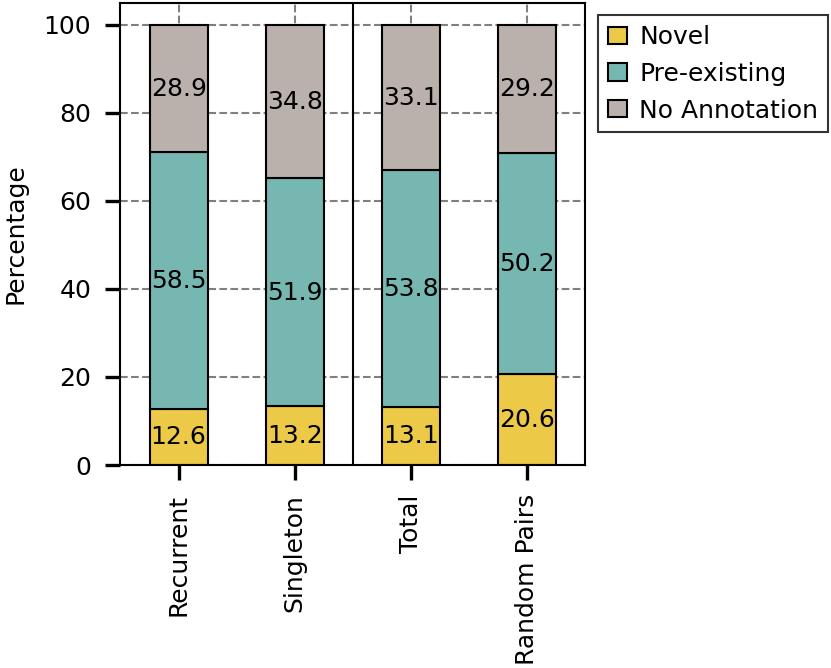

In [65]:
ax = full_cnt.div(full_totals).mul(100).T.plot.bar(stacked=True, edgecolor= 'k', linewidth =0.5, color = ['#EDC948','#76B7B2','#bab0ac'],zorder=2)
for c in ax.containers:
    ax.bar_label(c,fmt='%2.1f', label_type='center',size = 6)
plt.axvline(1.5, lw =0.5, color = 'k', ls= '-')
plt.ylabel('Percentage')
plt.tick_params(labelsize = 6)
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(2,2)
plt.grid(ls = '--', lw = 0.5,c = 'gray', zorder= -10)
plt.legend(bbox_to_anchor = (1,1),fontsize =6, handlelength = 0.75, handletextpad = 0.5).get_frame().set_linewidth(0.5)
plt.savefig('Figures/Manuscript/Figure_3/3C_Recurrent_DANSy_Distributions.svg')

# Additional Analysis that will not be included

Unfortunately there is some analysis that while interesting is not included in the manuscript. This includes looking at the Frame that the fusions are coming from and the relative expression levels. The Frame side of the analysis while potentially interesting is not that insightful and only reinforces that most of the fusion proteins with domain architectures involve CDS regions.

Another aspect is looking at relative expression of different fusion proteins between patients with and without them. However, there are not many fusions with a large enough cohort that has the fusion. The only one which has a sufficient number is the TMPRSS2-ERG cohort with >200 the rest of the fusions are either singletons or have 5-20 patients. The fusions with double-digit patients are a small fraction of the total cohort and makes any insights from the relative expression a little dubious.

In [46]:
# Small function to help with getting summary data

def get_category_summary(var, data=fusion_dansy_summary):
    temp = data.groupby(['Cancertype','dansy_impact'])[var].value_counts().unstack().fillna(0)
    temp = temp.transform(lambda x: x/temp.sum(axis=1)).reset_index()
    dataOI = temp.melt(id_vars=['Cancertype', 'dansy_impact'])

    return dataOI

In [47]:
# This is an attempt to get a simpler summary graphic for the fusions across the cancer types for the binary variables
colsOI = ['Kinase_involved','TF_involved','TS_involved','Oncogene_involved']
fusion_dansy_deduplicated = fusion_dansy_summary.filter(['name', 'dansy_impact', 'Cancertype', 'PatientID','domain_architecture']+colsOI).drop_duplicates(subset = ['name', 'dansy_impact', 'Cancertype', 'domain_architecture', 'PatientID'])
pos_frac_sum = pd.DataFrame()
for cat in colsOI:
    temp_data = get_category_summary(cat, fusion_dansy_deduplicated)
    if len(pos_frac_sum) < 1:
        pos_frac_sum = temp_data[temp_data[cat] == True].copy()
    else:
        pos_frac_sum = pos_frac_sum.merge(temp_data[temp_data[cat] == True].copy(),on = ['Cancertype','dansy_impact'])
    pos_frac_sum.drop(cat,axis =1, inplace=True)
    pos_frac_sum.rename(columns={'value':cat}, inplace=True)

full_frac = pd.DataFrame()
for cat in colsOI:
    temp = fusion_dansy_deduplicated.groupby(['Cancertype'])[cat].value_counts().unstack().fillna(0)
    temp = temp.transform(lambda x: x/temp.sum(axis=1)).reset_index().melt(id_vars='Cancertype')
    if len(full_frac) < 1:
        full_frac = temp[temp[cat] == True].copy()
    else:
        full_frac = full_frac.merge(temp[temp[cat] == True].copy(),on = ['Cancertype'])
    full_frac.drop(cat, axis=1, inplace=True)
    full_frac.rename(columns={'value':cat}, inplace=True)



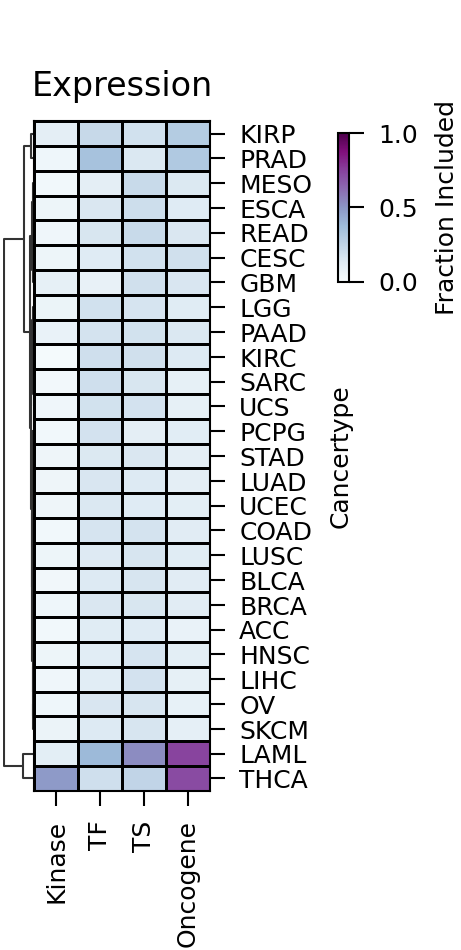

In [48]:
large_cohorts = fusion_counts[fusion_counts >= 75].index.tolist()
dataOI = full_frac[(full_frac['Cancertype'].isin(large_cohorts))].copy()
dataOI.rename(columns={'Kinase_involved':'Kinase','TF_involved':'TF','TS_involved':'TS','Oncogene_involved':'Oncogene' },inplace=True)
dataOI.set_index('Cancertype', inplace=True)
p = sns.clustermap(dataOI,yticklabels=True, cmap='BuPu', linecolor = 'k', linewidths=0.25,dendrogram_ratio=0.15,
                cbar_kws={'label':'Fraction Included'},
                method='ward',
                col_cluster=False,
                vmin =0,vmax=1,
                )
cx0,cy0,cw,ch = p.cbar_pos
p.ax_cbar.set_position([1.5,0.65,cw,ch])
cax = p.figure.get_children()[-1]
cax.spines['outline'].set_color('k')
cax.spines['outline'].set_linewidth(0.5)
cax.tick_params(width = 0.5, labelsize = 6)

plt.gcf().set_size_inches(0.75,2.75)
p.ax_heatmap.set_xticklabels(p.ax_heatmap.get_xticklabels(), rotation=90, size = 6)
p.ax_heatmap.set_yticklabels(p.ax_heatmap.get_yticklabels(), rotation=0, size = 6)
p.ax_heatmap.set_title('Expression', size =8)
p.ax_heatmap.tick_params(width = 0.5)
for _, spine in p.ax_heatmap.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
plt.show()
cbar_copy = p.ax_cbar
r_order = p.dendrogram_row.linkage
hp_row_order = dataOI.index[p.dendrogram_row.reordered_ind].tolist()

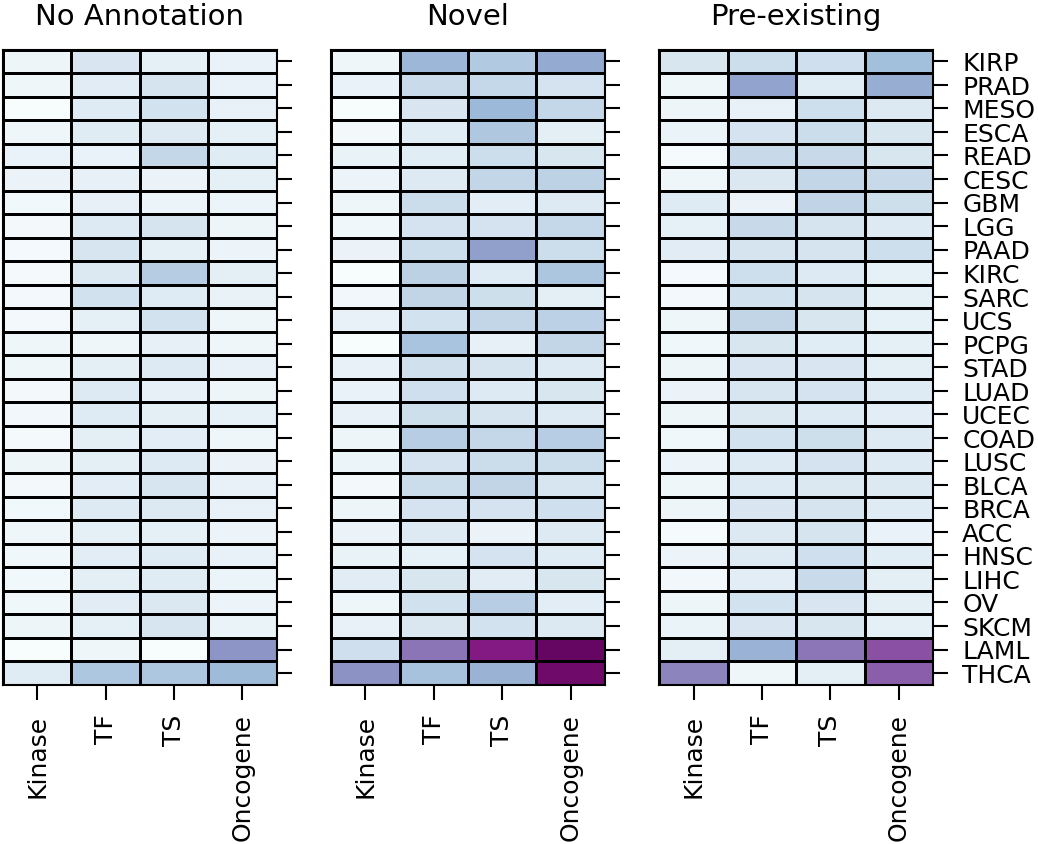

In [49]:
# Now plotting it via the a heatmap
f, axs = plt.subplots(1,3, sharex=True, sharey=True, figsize = (4,2.75))
# As part of the visual I will limit it to only cancers with >50 patients with fusions to limit influences from outliers
large_cohorts = fusion_counts[fusion_counts >= 75].index.tolist()
pos_frac_sum.rename(columns={'Kinase_involved':'Kinase','TF_involved':'TF','TS_involved':'TS','Oncogene_involved':'Oncogene' },inplace=True)
for i,fuscat in enumerate(pos_frac_sum.dansy_impact.unique()):
    dataOI = pos_frac_sum[(pos_frac_sum['dansy_impact'] == fuscat) & (pos_frac_sum['Cancertype'].isin(large_cohorts))].copy()
    dataOI['Cancertype'] = pd.Categorical(dataOI['Cancertype'], categories=hp_row_order, ordered=True)
    dataOI.drop('dansy_impact',axis = 1, inplace=True)
    dataOI.set_index('Cancertype', inplace=True)
    dataOI = dataOI.reindex(hp_row_order)
    draw_labs = fuscat == 'Pre-existing'

    p = sns.heatmap(dataOI,yticklabels=True, cmap='BuPu', linecolor = 'k', linewidths=0.25,
                    cbar = False,
                    vmin =0,vmax=1,
                    ax=axs[i])
    
    p.set_ylabel(None)
    p.set_title(fuscat, size=7)
    p.tick_params(width = 0.5, labelright = draw_labs, labelleft = False, left = False, right = True, labelsize = 6)
    if draw_labs:
        p.tick_params(axis = 'y', rotation = 0)
    for _, spine in p.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
plt.show()

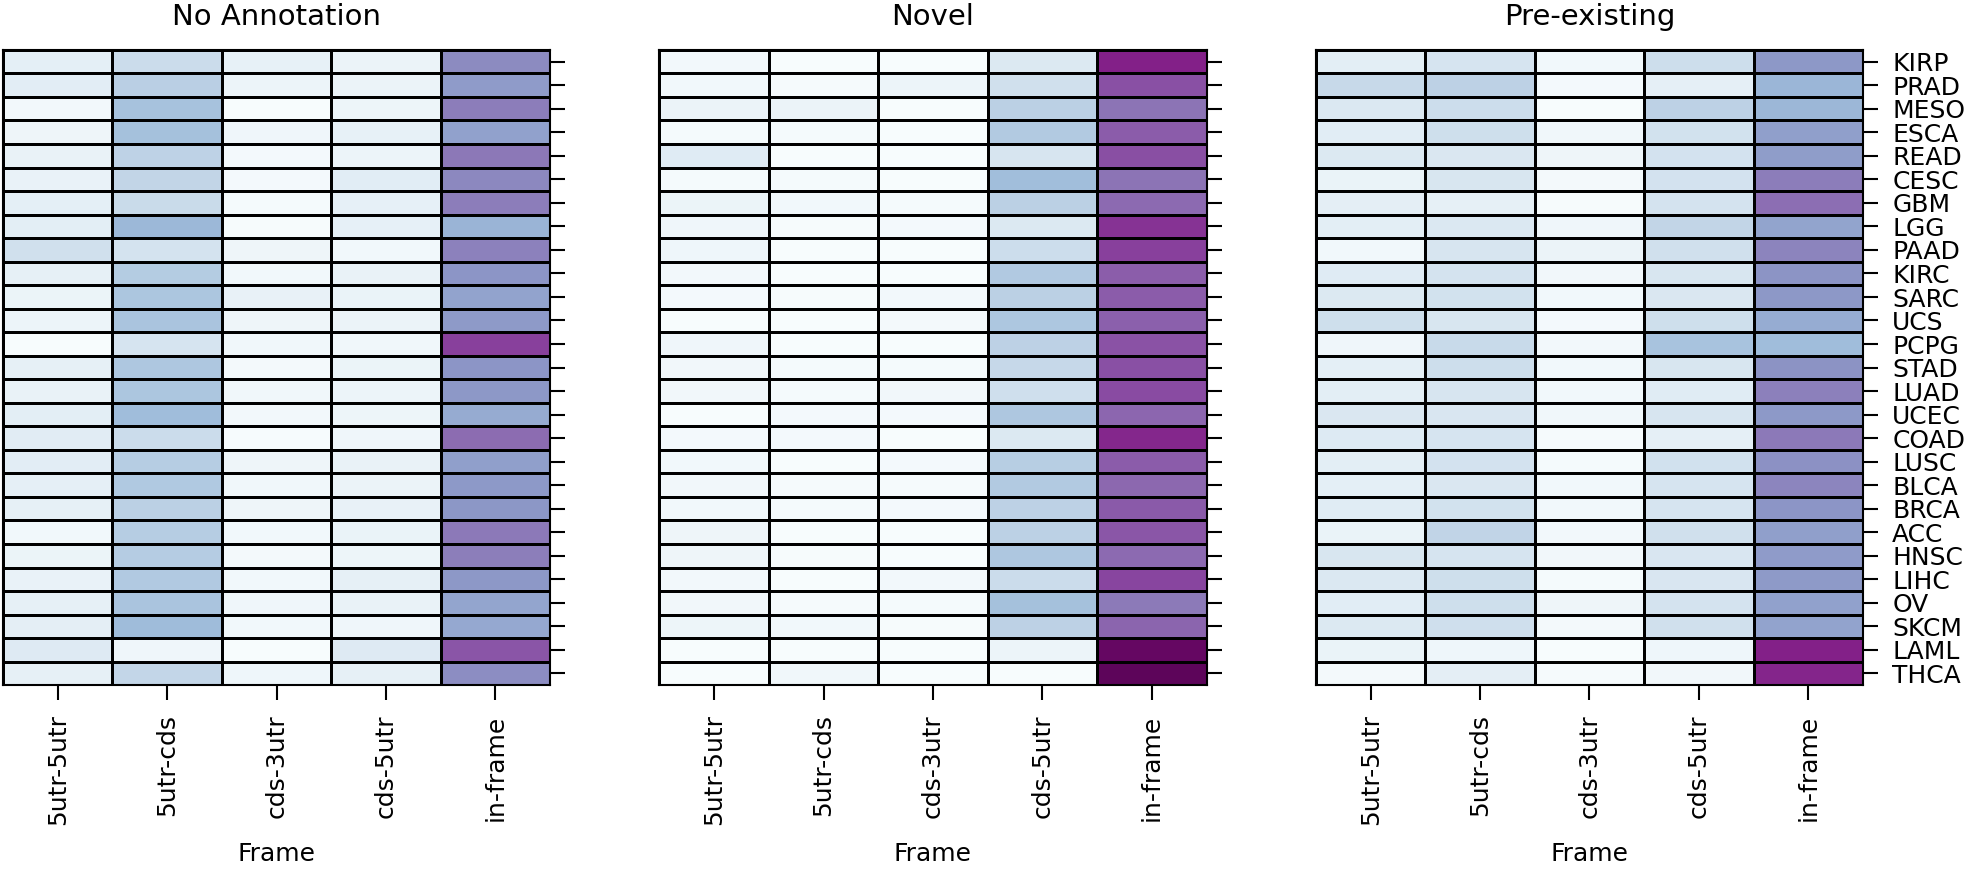

In [51]:
catOI = 'Frame'
fusion_dansy_summary['Frame'] = fusion_dansy_summary['Frame'].apply(fix_frame_str)
temp = fusion_dansy_summary.groupby(['Cancertype','dansy_impact'])[catOI].value_counts().unstack().fillna(0)
temp = temp.transform(lambda x: x/temp.sum(axis=1)).reset_index()
dataOI = temp.melt(id_vars=['Cancertype', 'dansy_impact'])
f, axs = plt.subplots(1,3, sharex=True, sharey=True, figsize = (8,2.75))
for i,fuscat in enumerate(dataOI.dansy_impact.unique()):
    plotData = dataOI[(dataOI['dansy_impact'] == fuscat) & (dataOI['Cancertype'].isin(large_cohorts))].copy()

    plotData['Cancertype'] = pd.Categorical(plotData['Cancertype'], categories=hp_row_order, ordered=True)
    plotData = plotData.pivot(columns='Frame', index=['Cancertype','dansy_impact'], values='value').reset_index()
    plotData.drop('dansy_impact',axis = 1, inplace=True)
    plotData.set_index('Cancertype', inplace=True)
    plotData = plotData.reindex(hp_row_order)
    draw_labs = fuscat == 'Pre-existing'


    p = sns.heatmap(plotData,yticklabels=True, cmap='BuPu', linecolor = 'k', linewidths=0.25,
                    cbar = False,
                    vmin =0,vmax=1,
                    ax = axs[i],xticklabels=True
                    )
    p.set_ylabel(None)
    p.set_title(fuscat, size=7)
    p.tick_params(width = 0.5, labelright = draw_labs, labelleft = False, left = False, right = True, labelsize = 6)
    if draw_labs:
        p.tick_params(axis = 'y', rotation = 0)
    for _, spine in p.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
plt.show()
